In [17]:
import numpy as np
import matplotlib.pyplot as plt
from model_ranking.utils import load_h5

In [ ]:
EtoE_path = "/scratch/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_EPFL_gap/feature_perturbation_consistency/FP_full/E_model4/norm_Normalize/none/predictions/test_predictions.h5"
EtoE_path_old = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_EPFL_gap/feature_perturbation_consistency/FP_3/E_model4/norm_Normalize/none/predictions/test_none.h5"

EtoE_preds = load_h5(EtoE_path, "predictions")
EtoE_preds_old = load_h5(EtoE_path_old, "predictions")  
EtoE_f1s = load_h5(EtoE_path, "hard_f1")
EtoE_f1s_old = load_h5(EtoE_path_old, "hard_f1")

In [4]:
print("EtoE predictions shape:", EtoE_preds.shape)
print("EtoE old predictions shape:", EtoE_preds_old.shape)

EtoE predictions shape: (750, 1, 1, 256, 256)
EtoE old predictions shape: (750, 1, 1, 256, 256)


In [5]:
print("EtoE f1 shape:", EtoE_f1s.shape)
print("EtoE old f1 shape:", EtoE_f1s_old.shape)

EtoE f1 shape: (750, 2)
EtoE old f1 shape: (750, 2)


In [6]:
is_same_f1 = np.all(np.isclose(EtoE_f1s, EtoE_f1s_old, atol=1e-5) | (np.isnan(EtoE_f1s) & np.isnan(EtoE_f1s_old)))
print("F1 scores are the same:", is_same_f1)

F1 scores are the same: False


In [10]:
EtoE_patch_indexes = load_h5(EtoE_path, "patch_index")
EtoE_patch_indexes_old = load_h5(EtoE_path_old, "patch_index")

In [11]:
np.all(EtoE_patch_indexes == EtoE_patch_indexes_old)

True

In [16]:
np.all(np.isclose(EtoE_preds, EtoE_preds_old, atol=1e-2))

False

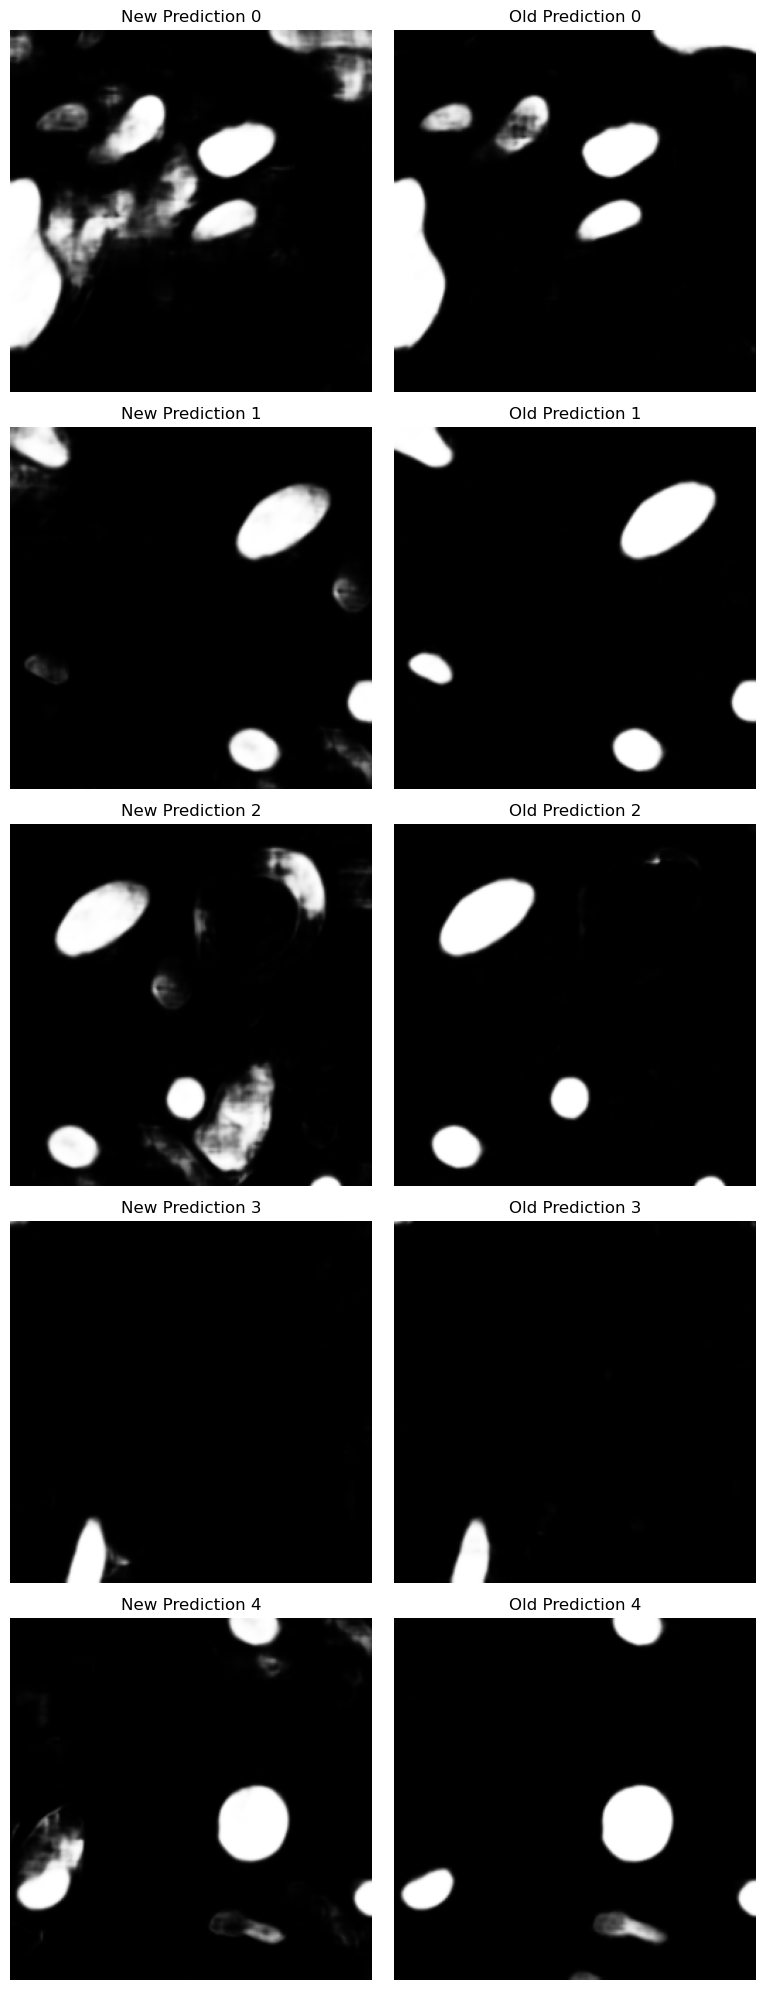

In [19]:
fig, axes = plt.subplots(5, 2, figsize=(8, 20))
for i in range(5):
    # Assuming the prediction shape is (N, 1, 256, 256) or (N, 256, 256)
    pred_new = EtoE_preds[i, 0] if EtoE_preds.ndim == 5 else EtoE_preds[i]
    pred_old = EtoE_preds_old[i, 0] if EtoE_preds_old.ndim == 5 else EtoE_preds_old[i]
    axes[i, 0].imshow(pred_new.squeeze(), cmap='gray')
    axes[i, 0].set_title(f'New Prediction {i}')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(pred_old.squeeze(), cmap='gray')
    axes[i, 1].set_title(f'Old Prediction {i}')
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

In [7]:
EtoE_f1s[:10]

array([[0.9635751 , 0.7309488 ],
       [0.9857461 , 0.82168627],
       [0.9672355 , 0.6402852 ],
       [0.9991031 , 0.9333334 ],
       [0.9900082 , 0.85165036],
       [0.98719776, 0.85485697],
       [0.9590877 , 0.6867445 ],
       [0.984044  , 0.8025712 ],
       [0.9664835 , 0.62686294],
       [0.9989261 , 0.9148805 ]], dtype=float32)

In [8]:
EtoE_f1s_old[:10]

array([[0.9902946 , 0.9176436 ],
       [0.99078745, 0.8927469 ],
       [0.9902062 , 0.8595835 ],
       [0.9992734 , 0.94490033],
       [0.991857  , 0.87509346],
       [0.99140054, 0.89737517],
       [0.9917662 , 0.9229675 ],
       [0.9905811 , 0.89021915],
       [0.9905695 , 0.86201555],
       [0.99916583, 0.93250006]], dtype=float32)